In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

In [6]:
import pandas as pd
df = pd.read_csv('stock market datasets...csv')

In [7]:
print(df.head())
print(df.info())

         Date  Close/Last     Volume      Open      High       Low
0  02/28/2020     $273.36  106721200   $257.26   $278.41   $256.37
1  02/27/2020     $273.52   80151380    $281.1      $286   $272.96
2  02/26/2020     $292.65   49678430   $286.53   $297.88    $286.5
3  02/25/2020     $288.08   57668360   $300.95   $302.53   $286.13
4  02/24/2020     $298.18   55548830   $297.26   $304.18   $289.23
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2518 entries, 0 to 2517
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         2518 non-null   object
 1    Close/Last  2518 non-null   object
 2    Volume      2518 non-null   int64 
 3    Open        2518 non-null   object
 4    High        2518 non-null   object
 5    Low         2518 non-null   object
dtypes: int64(1), object(5)
memory usage: 118.2+ KB
None


In [8]:
df.columns = df.columns.str.strip()

In [10]:
df['Date'] = pd.to_datetime(df['Date'], format='mixed')

In [11]:
df['Close/Last'] = df['Close/Last'].str.replace('$', '', regex=False).astype(float)

In [12]:
df.set_index('Date', inplace=True)

In [13]:
df = df.sort_index()

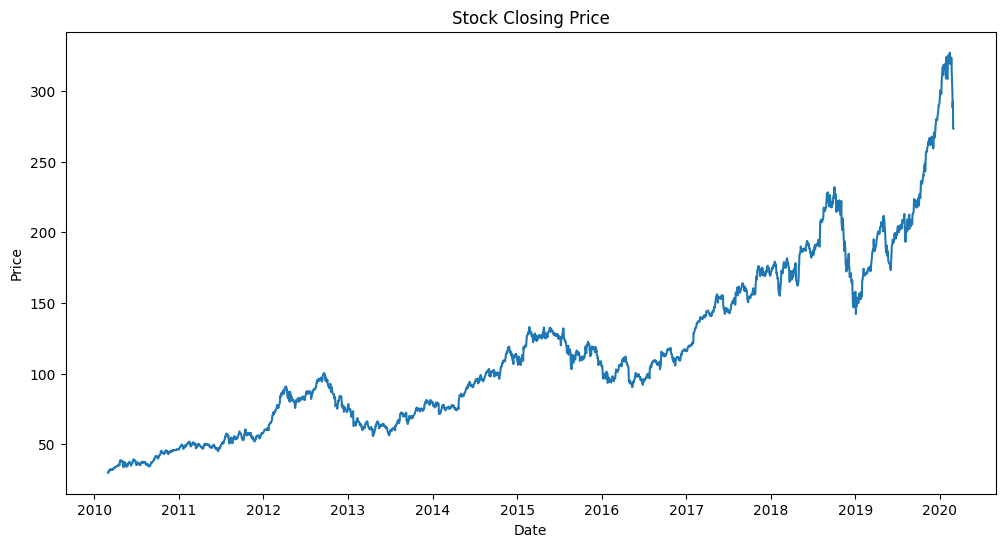

In [18]:
plt.figure(figsize=(12,6))
plt.plot(df['Close/Last'])
plt.title("Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [19]:
result = adfuller(df['Close/Last'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Data is Stationary")
else:
    print("Data is Non-Stationary")

ADF Statistic: 0.04918130127669495
p-value: 0.9624152269389331
Data is Non-Stationary


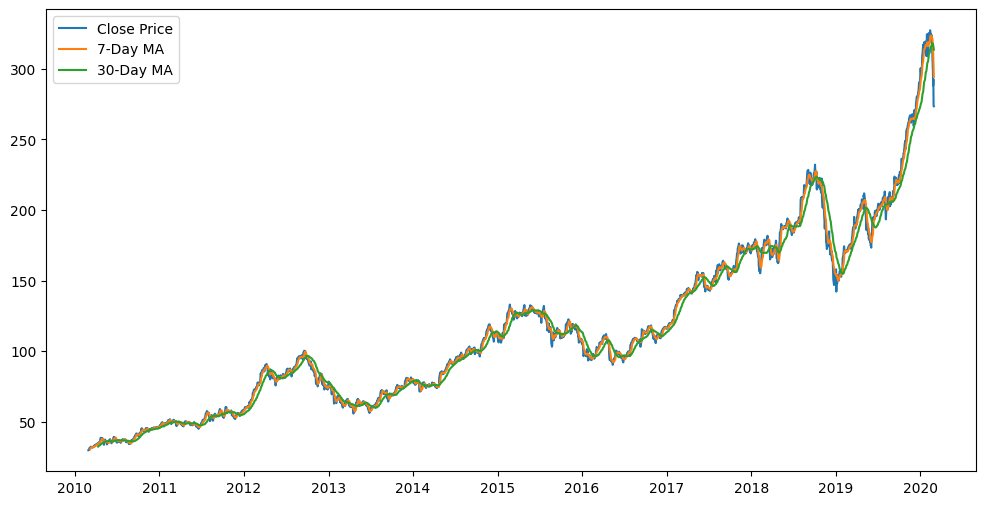

In [20]:
df['MA_7'] = df['Close/Last'].rolling(7).mean()
df['MA_30'] = df['Close/Last'].rolling(30).mean()

plt.figure(figsize=(12,6))
plt.plot(df['Close/Last'], label='Close Price')
plt.plot(df['MA_7'], label='7-Day MA')
plt.plot(df['MA_30'], label='30-Day MA')
plt.legend()
plt.show()

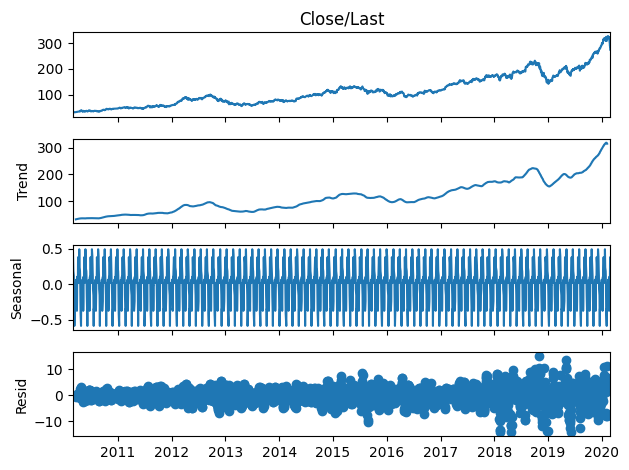

In [21]:
decomposition = seasonal_decompose(df['Close/Last'], model='additive', period=30)
decomposition.plot()
plt.show()

In [22]:
model = ARIMA(df['Close/Last'], order=(5,1,0))
model_fit = model.fit()

forecast = model_fit.forecast(steps=30)

print(forecast)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


2518    272.472630
2519    272.787556
2520    271.543979
2521    270.698421
2522    270.642758
2523    270.682243
2524    270.620109
2525    270.500290
2526    270.458885
2527    270.464096
2528    270.464980
2529    270.453781
2530    270.445114
2531    270.443942
2532    270.444736
2533    270.444145
2534    270.442984
2535    270.442504
2536    270.442558
2537    270.442587
2538    270.442481
2539    270.442390
2540    270.442375
2541    270.442385
2542    270.442381
2543    270.442369
2544    270.442364
2545    270.442364
2546    270.442365
2547    270.442364
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


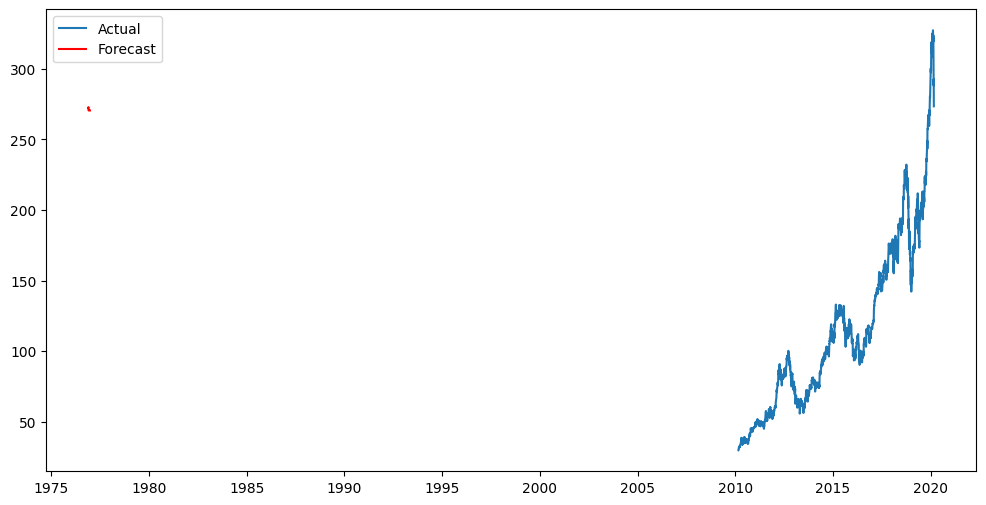

In [23]:
plt.figure(figsize=(12,6))
plt.plot(df['Close/Last'], label='Actual')
plt.plot(forecast.index, forecast, color='red', label='Forecast')
plt.legend()
plt.show()